In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy import stats
import numpy as np

In [45]:
df = pd.read_csv("All_predictions.csv")
df['observationTime'] = pd.to_datetime(df['observationTime'])
df.columns.to_list()

['observationTime',
 'rf_prediction',
 'actual',
 'ECMWF',
 'xgb_predicted',
 'SSA-LSTM']

In [73]:
pradzia = df['observationTime'].min()
pabaiga = df['observationTime'].max()
print(pradzia, pabaiga)

2024-08-11 00:00:00 2026-01-30 00:00:00


In [46]:
def calculate_metrics(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr, _ = stats.spearmanr(y_true, y_pred)
    
    return {
        'Modelis': model_name,
        'R^2': round(r2, 4),
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'r_s': round(corr, 4)
    }

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_rain_classification(data_frame, target_col, model_cols, rain_threshold=0.0):
    classification_results = []
    num_models = len(model_cols)

    fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5), squeeze=False)
    axes = axes.flatten() 
    
    for idx, model in enumerate(model_cols):
        y_true_bin = (data_frame[target_col] > rain_threshold).astype(int)
        y_pred_bin = (data_frame[model] > rain_threshold).astype(int)
    
        acc = accuracy_score(y_true_bin, y_pred_bin)
        prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
        rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
        f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
        
        classification_results.append({
            'Modelis': model,
            'Accuracy': round(acc, 3),
            'Precision': round(prec, 3),
            'Recall': round(rec, 3),
            'F1-Score': round(f1, 3)
        })
        
        cm = confusion_matrix(y_true_bin, y_pred_bin)
        sns.heatmap(
            cm, 
            annot=True,
            fmt="d", 
            cmap="Blues",
            xticklabels=['Nelyja', 'Lyja'], 
            yticklabels=['Nelyja', 'Lyja'],
            cbar=False,
            ax=axes[idx],
            annot_kws={"size": 14, "weight": "bold"}
        )
        
        axes[idx].set_title(f"Confusion Matrix: {model}", fontsize=12, pad=10)
        axes[idx].set_xlabel("Prognozė", fontsize=11)
        axes[idx].set_ylabel("Tikra", fontsize=11)
    
    plt.tight_layout()
    plt.show()
        
    summary_df = pd.DataFrame(classification_results)
    return summary_df

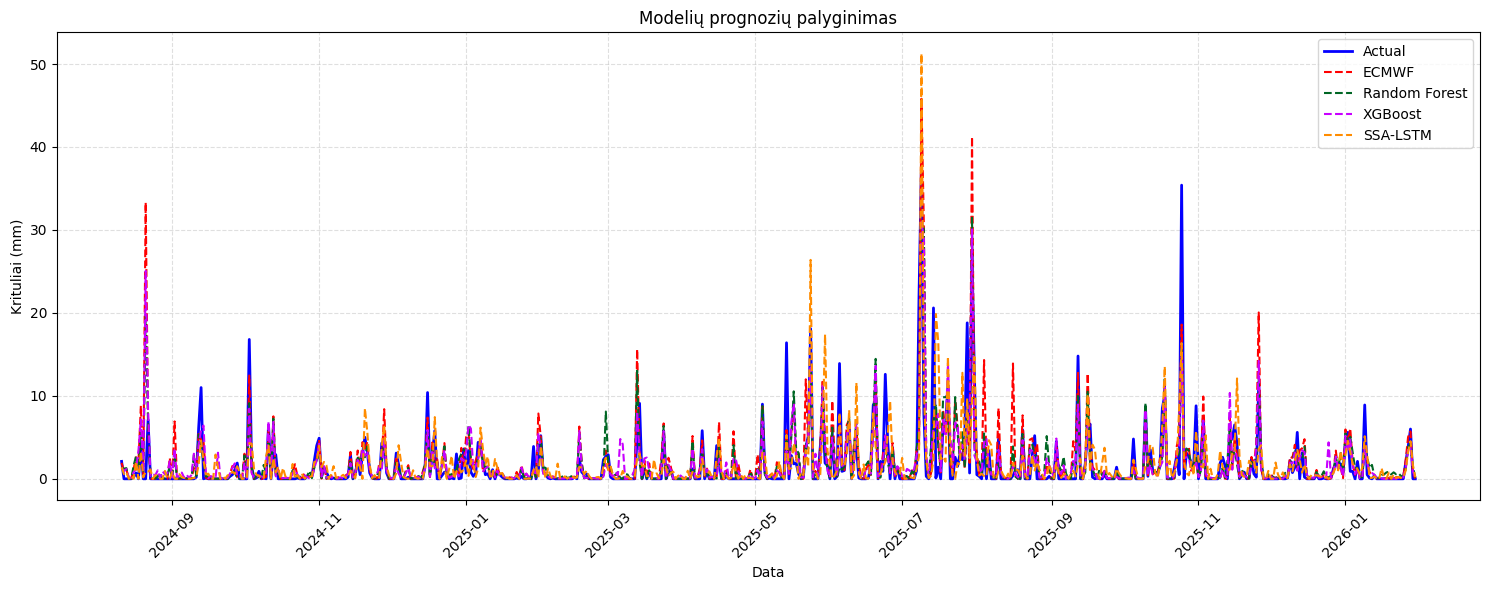

In [47]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df['observationTime'], df['actual'], label='Actual', color="#0400ff", linewidth=2)
ax.plot(df['observationTime'], df['ECMWF'], label='ECMWF', color="#FF0000", linewidth=1.5, linestyle='--')
ax.plot(df['observationTime'], df['rf_prediction'], label='Random Forest', color="#006624", linewidth=1.5, linestyle='--')
ax.plot(df['observationTime'], df['xgb_predicted'], label='XGBoost', color="#C800FF", linewidth=1.5, linestyle='--')
ax.plot(df['observationTime'], df['SSA-LSTM'], label='SSA-LSTM',  color="#FF8C00", linewidth=1.5, linestyle='--')

ax.set_xlabel('Data')
ax.set_ylabel('Krituliai (mm)')
ax.set_title('Modelių prognozių palyginimas')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=df['observationTime'], y=df['actual'], name='Actual', line=dict(color="#0400ff", width=1)))
fig.add_trace(go.Scatter(x=df['observationTime'], y=df['ECMWF'], name='ECMWF', line=dict(color="#FF0000", width=1, dash='dot')))
fig.add_trace(go.Scatter(x=df['observationTime'], y=df['rf_prediction'], name='Random Forest', line=dict(color="#006624", width=1, dash='dash')))
fig.add_trace(go.Scatter(x=df['observationTime'], y=df['xgb_predicted'], name='XGBoost', line=dict(color="#C800FF", width=1, dash='dashdot')))
fig.add_trace(go.Scatter(x=df['observationTime'], y=df['SSA-LSTM'], name='SSA-LSTM', line=dict(color="#FF8C00", width=1, dash='longdash')))

fig.update_layout(
    title='Modelių prognozių palyginimas',
    xaxis_title='Data',
    yaxis_title='Krituliai (mm)',
    hovermode='x unified',
    xaxis=dict(rangeslider=dict(visible=True)),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

fig.show()

### Visa turima aibė pagal lstm test

In [49]:
target_col = 'actual' 
model_cols = ['ECMWF', 'rf_prediction', 'xgb_predicted', 'SSA-LSTM'] 

results = []
for model in model_cols:
    metrics = calculate_metrics(df[target_col], df[model], model)
    results.append(metrics)

metrics_df = pd.DataFrame(results)
print(metrics_df.to_string(index=False))

      Modelis    R^2    MAE   RMSE    r_s
        ECMWF 0.3570 1.2996 3.0837 0.7410
rf_prediction 0.5118 1.2241 2.6869 0.7099
xgb_predicted 0.4735 1.2482 2.7904 0.6897
     SSA-LSTM 0.3870 1.4042 3.0108 0.6269


In [50]:
pradzia = df['observationTime'].min()
pabaiga = df['observationTime'].max()
df.shape

(538, 6)

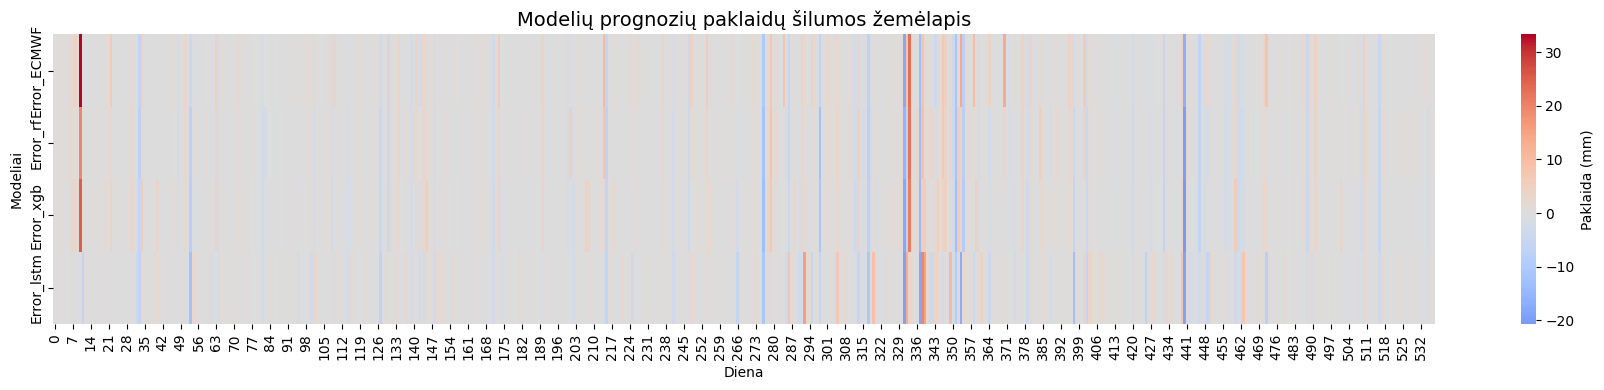

In [69]:
df['Error_ECMWF'] = df['ECMWF'] - df['actual']
df['Error_rf'] = df['rf_prediction'] - df['actual']
df['Error_xgb'] = df['xgb_predicted'] - df['actual']
df['Error_lstm'] = df['SSA-LSTM'] - df['actual']

error_cols = ['Error_ECMWF', 'Error_rf', 'Error_xgb', 'Error_lstm']
heatmap_data = df[error_cols].T

plt.figure(figsize=(18, 4))

sns.heatmap(heatmap_data, 
            cmap='coolwarm', 
            center=0, 
            cbar_kws={'label': 'Paklaida (mm)'})

plt.title('Modelių prognozių paklaidų šilumos žemėlapis', fontsize=14)
plt.xlabel('Diena')
plt.ylabel('Modeliai')
plt.tight_layout()
plt.show()

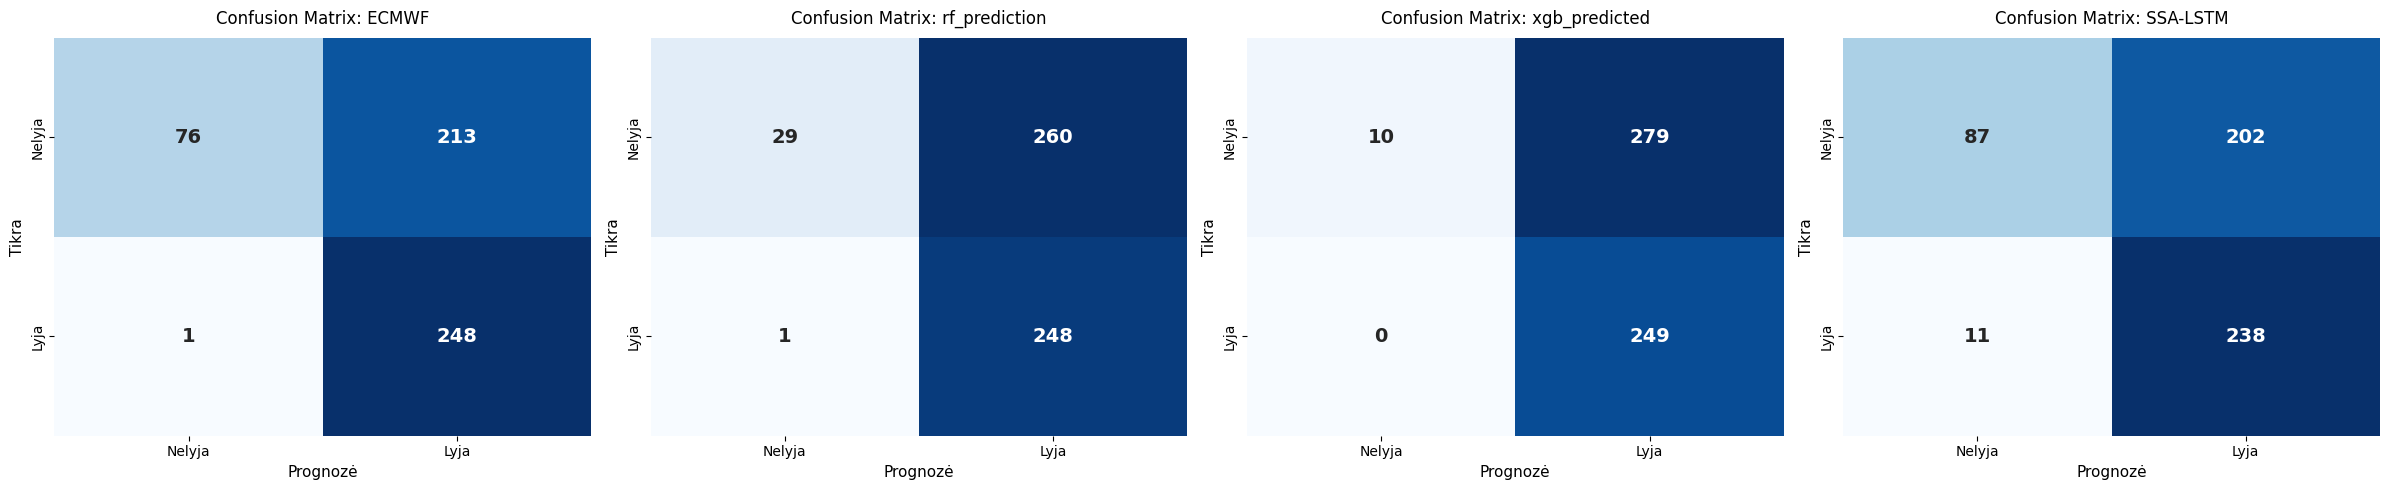

      Modelis  Accuracy  Precision  Recall  F1-Score
        ECMWF     0.602      0.538   0.996     0.699
rf_prediction     0.515      0.488   0.996     0.655
xgb_predicted     0.481      0.472   1.000     0.641
     SSA-LSTM     0.604      0.541   0.956     0.691


In [62]:
suvestine_visi = evaluate_rain_classification(df, target_col, model_cols, rain_threshold=0.0)
print(suvestine_visi.to_string(index=False))

### Tik test aibė (paskutiniai metai)

In [51]:
paskutine_data = df['observationTime'].max()
pries_metus = paskutine_data - pd.Timedelta(days=365)

df_365 = df[(df['observationTime'] > pries_metus) & (df['observationTime'] <= paskutine_data)]

print(f"Paskutinių 12 mėn. duomenų taškai: {len(df_365)}")

Paskutinių 12 mėn. duomenų taškai: 365


In [52]:
results_365 = []
for model in model_cols:
    metrics_365 = calculate_metrics(df_365[target_col], df_365[model], model)
    results_365.append(metrics_365)

metrics_df_365 = pd.DataFrame(results_365)
print(metrics_df_365.to_string(index=False))

      Modelis    R^2    MAE   RMSE    r_s
        ECMWF 0.4846 1.4452 3.1535 0.7647
rf_prediction 0.5520 1.3928 2.9401 0.7325
xgb_predicted 0.5523 1.3588 2.9392 0.7228
     SSA-LSTM 0.3812 1.6342 3.4553 0.6391


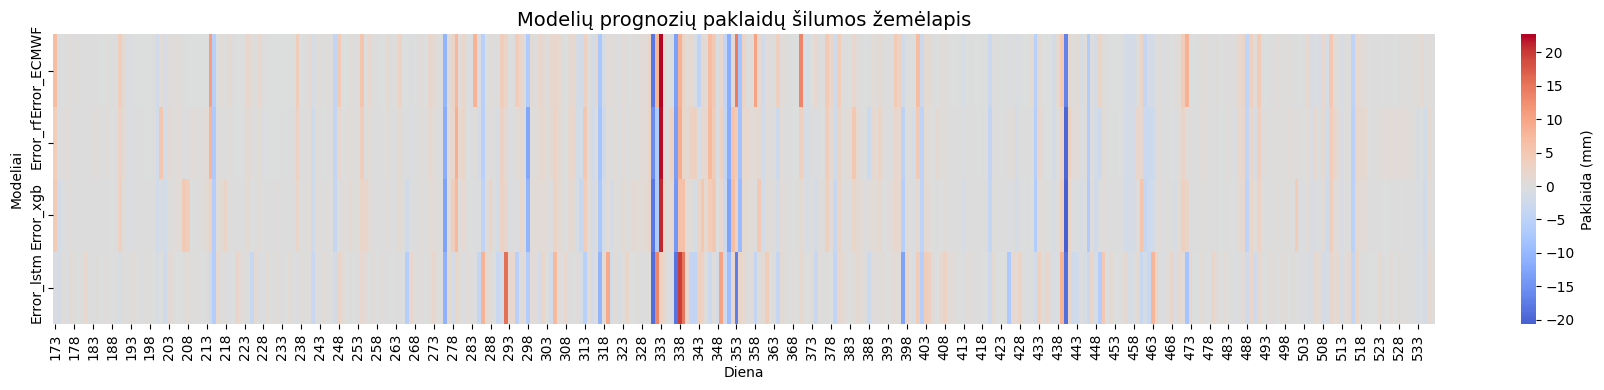

In [70]:
df_365['Error_ECMWF'] = df_365['ECMWF'] - df_365['actual']
df_365['Error_rf'] = df_365['rf_prediction'] - df_365['actual']
df_365['Error_xgb'] = df_365['xgb_predicted'] - df_365['actual']
df_365['Error_lstm'] = df_365['SSA-LSTM'] - df_365['actual']

error_cols = ['Error_ECMWF', 'Error_rf', 'Error_xgb', 'Error_lstm']
heatmap_data = df_365[error_cols].T

plt.figure(figsize=(18, 4))

sns.heatmap(heatmap_data, 
            cmap='coolwarm', 
            center=0, 
            cbar_kws={'label': 'Paklaida (mm)'})

plt.title('Modelių prognozių paklaidų šilumos žemėlapis', fontsize=14)
plt.xlabel('Diena')
plt.ylabel('Modeliai')
plt.tight_layout()
plt.show()

### Itrauktas ansamblis

In [75]:
df_ensemble = pd.read_csv("All_with_ensemble_rf.csv")
df_ensemble['observationTime'] = pd.to_datetime(df_ensemble['observationTime'])
df_ensemble.columns.to_list()
pradzia = df_ensemble['observationTime'].min()
pabaiga = df_ensemble['observationTime'].max()
print(pradzia, pabaiga)

2024-02-02 00:00:00 2026-01-31 00:00:00


In [76]:
df_subset = df[["observationTime", "SSA-LSTM"]]

df_combined = pd.merge(
    df_ensemble, df_subset, on="observationTime", how="left"
)

print("\nNauji stulpeliai:", df_combined.columns.to_list())
print("Eiluciu skaicius po sujungimo:", len(df_combined))


Nauji stulpeliai: ['observationTime', 'rf_prediction', 'actual', 'ECMWF', 'xgb_predicted', 'ensemble_rf_pred', 'SSA-LSTM']
Eilučių skaičius po sujungimo: 730


In [95]:
first_valid_index = df_combined["ensemble_rf_pred"].first_valid_index()

df_cut = df_combined.loc[first_valid_index:].copy()
df_final = df_cut.dropna()

print(f"Rinkinys nukirptas nuo indekso: {first_valid_index}")
print(f"Nauja pradžios data: {df_final['observationTime'].min()}")

Rinkinys nukirptas nuo indekso: 584
Nauja pradžios data: 2025-09-08 00:00:00


In [96]:
df_final

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted,ensemble_rf_pred,SSA-LSTM
584,2025-09-08,0.037,0.0,0.007629,0.317399,0.880,0.000000
585,2025-09-09,0.004,0.0,0.024434,0.737036,0.115,0.559524
586,2025-09-10,2.044,0.0,4.535957,2.170876,2.732,0.976370
587,2025-09-11,1.767,0.0,3.345291,1.599152,2.605,0.291754
588,2025-09-12,9.987,14.8,12.769258,8.959787,9.762,1.840478
...,...,...,...,...,...,...,...
724,2026-01-26,1.137,1.9,2.256399,1.226669,1.790,0.986049
725,2026-01-27,3.763,3.8,5.037111,3.614739,2.147,3.230480
726,2026-01-28,4.277,6.0,5.703954,3.818949,4.124,4.536834
727,2026-01-29,1.372,0.0,0.669112,0.865018,0.330,1.657489


In [92]:
target_col = 'actual' 
model_cols = ['ECMWF', 'rf_prediction', 'xgb_predicted', 'SSA-LSTM', 'ensemble_rf_pred'] 

results = []
for model in model_cols:
    metrics = calculate_metrics(df_final[target_col], df_final[model], model)
    results.append(metrics)

metrics_df = pd.DataFrame(results)
print(metrics_df.to_string(index=False))

         Modelis    R^2    MAE   RMSE    r_s
           ECMWF 0.6461 1.0555 2.2799 0.7706
   rf_prediction 0.6389 1.0865 2.3029 0.7264
   xgb_predicted 0.6084 1.0439 2.3981 0.7498
        SSA-LSTM 0.4649 1.4386 2.8033 0.6175
ensemble_rf_pred 0.6658 0.9783 2.2155 0.7615
